# Tugas Praktikum 2: Praproses Data

**Nama:** Rayyan Muhtar Ali  
**NRP:** 5054251051  
**Mata Kuliah:** Penambangan Data

**Dataset:** House Prices - Advanced Regression Techniques (Kaggle), file `train.csv`, 1460 baris dan 81 kolom.  
Link: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

Isinya data penjualan rumah di Ames, Iowa. Satu baris satu rumah, kolomnya campur-campur: luas bangunan, luas tanah, tahun dibangun, jumlah kamar, tipe pondasi, sampai penilaian kualitas material dan kondisi rumah. Kolom `SalePrice` adalah harga jualnya.

Yang saya kerjakan di sini ada lima tahap: bersihkan nilai hilang, tangani outlier, transformasi (log, standarisasi, one-hot encoding), reduksi dimensi lewat korelasi dan PCA, lalu simpan dataset akhirnya.

## 1. Import dan Pemahaman Dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

In [2]:
df_mentah = pd.read_csv("train.csv")

print("Jumlah baris dan kolom:", df_mentah.shape)
df_mentah.head()

Jumlah baris dan kolom: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,...,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,...,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,...,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df_mentah.info(max_cols=81)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
df_mentah.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

Dari 81 kolom, 38 bertipe angka dan 43 bertipe teks. Satu kolom (`Id`) cuma nomor urut, tidak ada gunanya buat analisis, nanti dibuang.

Tapi sebelum lanjut ada satu hal yang perlu dibereskan dulu soal cara bacanya.

In [5]:
print("MasVnrType yang terbaca hilang:", df_mentah["MasVnrType"].isna().sum())

# baca ulang apa adanya, tanpa penerjemahan nilai kosong bawaan pandas
cek = pd.read_csv("train.csv", keep_default_na=False, dtype=str)
print()
print(cek["MasVnrType"].value_counts().to_string())

MasVnrType yang terbaca hilang: 872

MasVnrType
None       864
BrkFace    445
Stone      128
BrkCmn      15
NA           8


Nah, ketahuan. Di file aslinya nilai kosong ditulis `NA`, dan `MasVnrType` cuma punya 8 sel `NA`. Sisanya yang 864 itu isinya kata `None`, artinya rumahnya memang tidak pakai lapisan batu hias di dinding. Itu kategori yang sah, bukan data hilang. Masalahnya `None` termasuk daftar kata yang otomatis dianggap kosong sama pandas, jadi kalau dibaca dengan setelan bawaan kolom ini kelihatan hilang 59,7% padahal sebenarnya cuma 0,55%.

Kalau dibiarkan, `MasVnrType` bakal kena aturan pembuangan kolom di atas 50% padahal datanya lengkap. Jadi saya baca ulang dan tentukan sendiri mana yang dihitung kosong.

In [6]:
df_mentah = pd.read_csv("train.csv", keep_default_na=False, na_values=["NA", ""])

print("MasVnrType hilang setelah dibaca ulang:", df_mentah["MasVnrType"].isna().sum())
print("Total sel kosong di seluruh tabel:", df_mentah.isna().sum().sum())

MasVnrType hilang setelah dibaca ulang: 8
Total sel kosong di seluruh tabel: 6965


## 2. Pembersihan Data

### 2.1 Nilai yang hilang

In [7]:
hilang = pd.DataFrame({
    "jumlah": df_mentah.isna().sum(),
    "persen": (df_mentah.isna().mean() * 100).round(2),
})
hilang = hilang[hilang["jumlah"] > 0].sort_values("persen", ascending=False)

print("Jumlah kolom yang punya nilai hilang:", len(hilang))
hilang

Jumlah kolom yang punya nilai hilang: 19


,jumlah,persen
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageCond,81,5.55
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


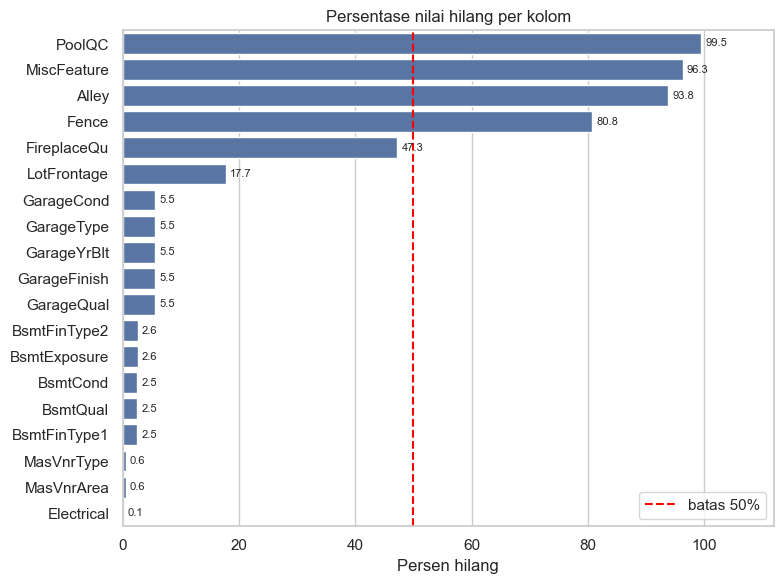

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=hilang["persen"], y=hilang.index, color="#4c72b0", ax=ax)
ax.axvline(50, color="red", linestyle="--", label="batas 50%")
ax.bar_label(ax.containers[0], fmt="%.1f", padding=3, fontsize=8)
ax.set_title("Persentase nilai hilang per kolom")
ax.set_xlabel("Persen hilang")
ax.set_ylabel("")
ax.set_xlim(0, 112)
ax.legend()
plt.tight_layout()
plt.show()

Ada 19 kolom yang tidak lengkap, dan empat di antaranya lewat garis merah: `PoolQC` (99,5%), `MiscFeature` (96,3%), `Alley` (93,8%), dan `Fence` (80,8%). Sesuai ketentuan praktikum, keempatnya dibuang.

Sebenarnya isi keempat kolom itu juga hampir seragam, jadi tidak rugi dibuang. Contohnya `PoolQC`: cuma 7 rumah dari 1460 yang punya kolam renang, jadi kolom ini praktis konstan dan tidak bisa membedakan apa-apa.

In [9]:
df = df_mentah.drop(columns=["Id"])

kolom_buang = hilang[hilang["persen"] > 50].index.tolist()
df = df.drop(columns=kolom_buang)

print("Kolom yang dibuang:", kolom_buang)
print("Sisa kolom:", df.shape[1])
print("Rumah yang punya kolam renang:", (df_mentah["PoolArea"] > 0).sum())

Kolom yang dibuang: ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
Sisa kolom: 76
Rumah yang punya kolam renang: 7


### Kosong yang artinya "tidak punya"

Sisa kolom yang hilang tidak bisa langsung ditambal pakai modus atau median. Di dokumentasi datasetnya, `NA` pada kolom fasilitas itu artinya rumahnya memang tidak punya fasilitas tersebut. Gampang dibuktikan: tinggal dicocokkan dengan kolom luas atau jumlahnya.

In [10]:
bukti = pd.DataFrame([
    ["FireplaceQu", df["FireplaceQu"].isna().sum(), "Fireplaces == 0", (df["Fireplaces"] == 0).sum()],
    ["GarageType", df["GarageType"].isna().sum(), "GarageArea == 0", (df["GarageArea"] == 0).sum()],
    ["BsmtQual", df["BsmtQual"].isna().sum(), "TotalBsmtSF == 0", (df["TotalBsmtSF"] == 0).sum()],
    ["BsmtExposure", df["BsmtExposure"].isna().sum(), "TotalBsmtSF == 0", (df["TotalBsmtSF"] == 0).sum()],
], columns=["kolom", "jumlah_kosong", "dicocokkan_dengan", "jumlah_cocok"])

bukti

,kolom,jumlah_kosong,dicocokkan_dengan,jumlah_cocok
0,FireplaceQu,690,Fireplaces == 0,690
1,GarageType,81,GarageArea == 0,81
2,BsmtQual,37,TotalBsmtSF == 0,37
3,BsmtExposure,38,TotalBsmtSF == 0,37


Tiga baris pertama angkanya sama persis, jadi kosongnya bukan karena data hilang tapi karena rumahnya memang tidak punya perapian, garasi, atau basement. Untuk kolom seperti ini nilai kosongnya saya ganti jadi kategori `None`.

`BsmtExposure` menarik: kosongnya 38 padahal rumah tanpa basement cuma 37. Berarti ada satu rumah yang basementnya ada tapi keterangannya benar-benar hilang. Yang satu ini baru pantas diisi modus. Hal yang sama terjadi di `BsmtFinType2`.

In [11]:
fitur_none = ["FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond",
              "BsmtQual", "BsmtCond", "BsmtFinType1", "MasVnrType"]
for kol in fitur_none:
    df[kol] = df[kol].fillna("None")

# satu rumah punya basement tapi keterangannya kosong, itu saja yang diisi modus
punya_basement = df["TotalBsmtSF"] > 0
for kol in ["BsmtExposure", "BsmtFinType2"]:
    df.loc[punya_basement, kol] = df.loc[punya_basement, kol].fillna(df[kol].mode()[0])
    df[kol] = df[kol].fillna("None")

print(df[["FireplaceQu", "GarageType", "BsmtExposure"]].isna().sum())

FireplaceQu     0
GarageType      0
BsmtExposure    0
dtype: int64


In [12]:
# rumah tanpa garasi: pakai tahun rumahnya dibangun, bukan 0, supaya skala tahunnya tidak rusak
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["YearBuilt"])

# 8 rumah yang MasVnrType-nya hilang tadi luas lapisannya juga kosong, berarti tidak ada lapisannya
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

# cuma 1 baris, diisi jenis instalasi listrik yang paling umum
print("Electrical sebelum diisi:", df["Electrical"].isna().sum(), "| modus:", df["Electrical"].mode()[0])
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

Electrical sebelum diisi: 1 | modus: SBrkr


Tinggal `LotFrontage`, panjang sisi rumah yang menghadap jalan, hilang 259 baris (17,7%). Ini yang paling banyak dan tidak ada kolom lain yang bisa dipakai buat memastikan artinya "tidak punya" -- semua rumah pasti punya sisi depan.

Isi pakai median keseluruhan sebenarnya bisa, tapi kurang pas. Rumah di satu kompleks biasanya kaplingnya seragam, jadi median per `Neighborhood` lebih masuk akal daripada satu angka untuk semua.

In [13]:
print("Median LotFrontage per kompleks (10 teratas):")
print(df.groupby("Neighborhood")["LotFrontage"].median().sort_values(ascending=False).head(10).to_string())

sebelum = df["LotFrontage"].describe()[["mean", "std", "50%"]]
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda s: s.fillna(s.median()))

pd.DataFrame({"sebelum": sebelum, "sesudah": df["LotFrontage"].describe()[["mean", "std", "50%"]]}).round(2)

Median LotFrontage per kompleks (10 teratas):
Neighborhood
NoRidge    91.0
NridgHt    88.5
Timber     85.0
NWAmes     80.0
ClearCr    80.0
Crawfor    74.0
Somerst    73.5
NAmes      73.0
Mitchel    73.0
Sawyer     71.0


,sebelum,sesudah
mean,70.05,70.20
std,24.28,22.43
50%,69.00,70.00


Medianya tidak bergeser dan standar deviasinya cuma turun sedikit, jadi menambal 259 baris ini tidak bikin sebarannya berubah banyak.

In [14]:
print("Sisa nilai hilang di seluruh tabel:", df.isna().sum().sum())

Sisa nilai hilang di seluruh tabel: 0


### 2.2 Data yang tidak konsisten

Nilai hilang beres. Sekarang cek hal-hal yang secara logika tidak mungkin.

In [15]:
print("Baris duplikat:", df.duplicated().sum())
print("Nilai numerik negatif:", int((df.select_dtypes(np.number) < 0).sum().sum()))
print("Direnovasi sebelum dibangun:", (df["YearRemodAdd"] < df["YearBuilt"]).sum())
print("Garasi dibangun setelah rumah dijual:", (df["GarageYrBlt"] > df["YrSold"]).sum())
print("Luas lantai 1 + lantai 2 tidak sama dengan GrLivArea:",
      (df["1stFlrSF"] + df["2ndFlrSF"] + df["LowQualFinSF"] != df["GrLivArea"]).sum())
print()
print(df["Utilities"].value_counts().to_string())

Baris duplikat: 0
Nilai numerik negatif: 0
Direnovasi sebelum dibangun: 0
Garasi dibangun setelah rumah dijual: 0
Luas lantai 1 + lantai 2 tidak sama dengan GrLivArea: 0

Utilities
AllPub    1459
NoSeWa       1


Bersih, tidak ada yang aneh. Tahun renovasi tidak pernah mendahului tahun bangun, tidak ada luas bernilai negatif, dan penjumlahan luas per lantai cocok dengan luas total.

Yang bermasalah justru `Utilities`: 1459 dari 1460 baris isinya `AllPub`. Kolom yang isinya seragam begini tidak bisa membedakan satu rumah dengan rumah lain, jadi saya buang.

Satu lagi, `MSSubClass` tersimpan sebagai angka (20, 60, 120, ...) padahal itu kode tipe bangunan, bukan besaran. Kalau dibiarkan numerik nanti ikut distandarisasi dan dianggap 120 lebih besar dari 20, padahal tidak ada artinya. Saya ubah jadi teks supaya nanti kena one-hot encoding.

In [16]:
df = df.drop(columns=["Utilities"])
df["MSSubClass"] = df["MSSubClass"].astype(str)

print("Ukuran data setelah pembersihan:", df.shape)

Ukuran data setelah pembersihan: (1460, 75)


## 3. Deteksi dan Penanganan Outlier

Deteksinya pakai aturan IQR: nilai di luar rentang Q1 - 1,5 x IQR sampai Q3 + 1,5 x IQR dihitung outlier.

In [17]:
def batas_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


kolom_num = df.select_dtypes(np.number).columns.tolist()

baris = []
for kol in kolom_num:
    bawah, atas = batas_iqr(df[kol])
    n = int(((df[kol] < bawah) | (df[kol] > atas)).sum())
    baris.append({
        "kolom": kol,
        "jumlah_outlier": n,
        "persen": round(n / len(df) * 100, 2),
        "skewness": round(df[kol].skew(), 2),
    })

tabel_outlier = pd.DataFrame(baris).sort_values("jumlah_outlier", ascending=False)

print("Kolom numerik:", len(kolom_num))
print("Kolom yang punya outlier:", (tabel_outlier["jumlah_outlier"] > 0).sum())
tabel_outlier.head(12)

Kolom numerik: 36
Kolom yang punya outlier: 31


,kolom,jumlah_outlier,persen,skewness
28,EnclosedPorch,208,14.25,3.09
8,BsmtFinSF2,167,11.44,4.26
3,OverallCond,125,8.56,0.69
30,ScreenPorch,116,7.95,4.12
6,MasVnrArea,98,6.71,2.68
0,LotFrontage,93,6.37,2.21
16,BsmtHalfBath,82,5.62,4.10
27,OpenPorchSF,77,5.27,2.36
1,LotArea,69,4.73,12.21
20,KitchenAbvGr,68,4.66,4.49


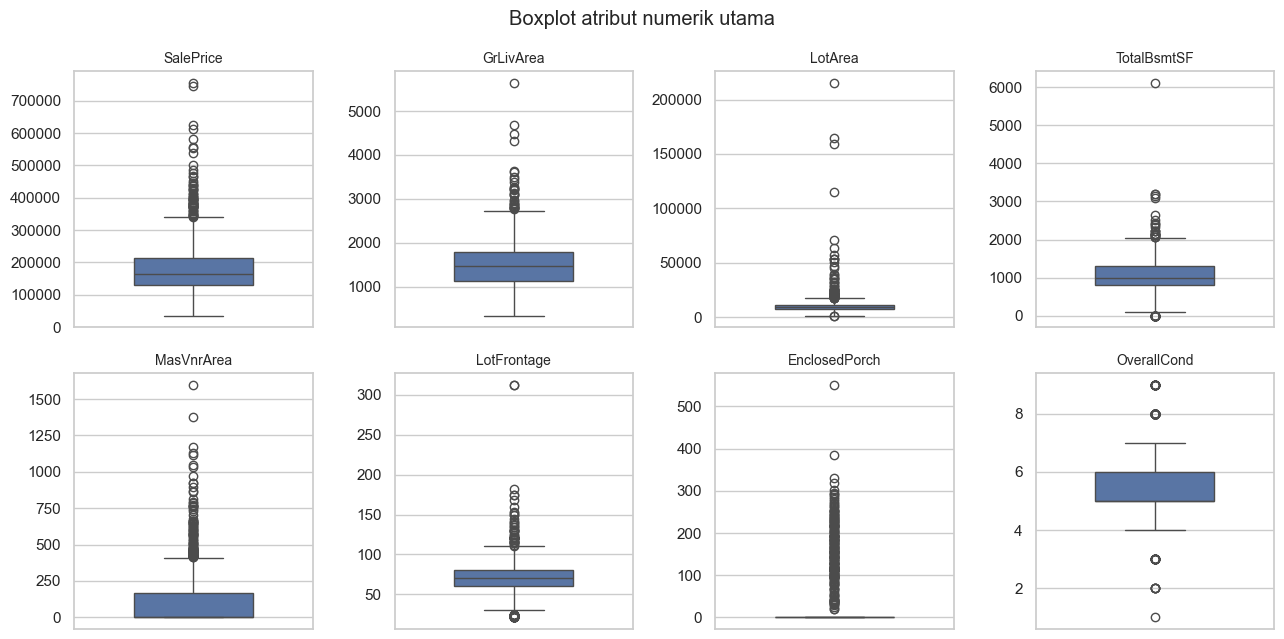

In [18]:
pilih = ["SalePrice", "GrLivArea", "LotArea", "TotalBsmtSF",
         "MasVnrArea", "LotFrontage", "EnclosedPorch", "OverallCond"]

fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for ax, kol in zip(axes.ravel(), pilih):
    sns.boxplot(y=df[kol], ax=ax, color="#4c72b0", width=0.5)
    ax.set_title(kol, fontsize=10)
    ax.set_ylabel("")

fig.suptitle("Boxplot atribut numerik utama")
plt.tight_layout()
plt.show()

Hampir semua kolom numerik punya outlier versi IQR, tapi begitu dilihat isinya kebanyakan bukan kesalahan input. `EnclosedPorch` misalnya, 14,3% barisnya dianggap outlier cuma karena mayoritas rumah nilainya 0 (tidak punya teras tertutup), jadi begitu ada yang punya langsung dianggap ekstrem. Pola yang sama terjadi di `BsmtFinSF2`, `ScreenPorch`, dan `MasVnrArea`.

`LotArea` dan `SalePrice` beda cerita: nilainya memang menceng ke kanan karena ada rumah yang tanahnya luar biasa luas dan ada rumah mewah yang harganya jauh di atas rata-rata. Itu variasi nyata di pasar rumah, bukan salah catat.

Kalau semua outlier IQR dibuang, datanya habis banyak sekali dan justru menghilangkan segmen rumah mahal yang ingin dipelajari. Jadi saya tidak main hapus. Yang saya cari adalah baris yang polanya benar-benar janggal.

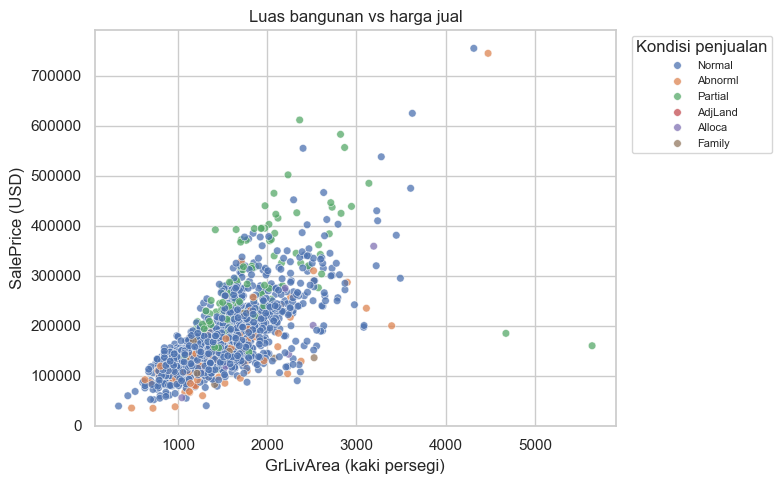

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="GrLivArea", y="SalePrice", hue="SaleCondition",
                alpha=0.75, s=30, ax=ax)
ax.set_title("Luas bangunan vs harga jual")
ax.set_xlabel("GrLivArea (kaki persegi)")
ax.set_ylabel("SalePrice (USD)")
ax.legend(title="Kondisi penjualan", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [20]:
df.loc[df["GrLivArea"] > 4000,
       ["GrLivArea", "SalePrice", "OverallQual", "YearBuilt", "SaleCondition"]]

,GrLivArea,SalePrice,OverallQual,YearBuilt,SaleCondition
523,4676,184750,10,2007,Partial
691,4316,755000,10,1994,Normal
1182,4476,745000,10,1996,Abnorml
1298,5642,160000,10,2008,Partial


Di scatter plot itu ada dua titik yang jelas melenceng dari tren: luas bangunannya paling besar (4676 dan 5642 kaki persegi) tapi harganya justru di bawah 200 ribu, padahal dua rumah lain yang seukuran laku 745 ribu dan 755 ribu. Kualitas bangunannya sama-sama 10.

Kolom `SaleCondition` menjelaskan penyebabnya: dua rumah itu berstatus `Partial`, artinya rumahnya dijual dalam keadaan belum selesai dibangun. Harganya jadi tidak mencerminkan nilai rumah jadi. Dua baris ini memang biasa dibuang di dataset ini, dan alasannya kuat, jadi saya hapus.

In [21]:
buang = (df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)
print("Baris yang dibuang:", int(buang.sum()))

df = df[~buang].reset_index(drop=True)
print("Ukuran data sekarang:", df.shape)

Baris yang dibuang: 2
Ukuran data sekarang: (1458, 75)


Sisa outliernya tetap dipakai. Tapi bukan berarti dibiarkan begitu saja: sebaran yang menceng seperti `LotArea` (skewness 12,6) bikin standarisasi jadi timpang dan PCA gampang didominasi satu-dua kolom. Itu ditangani di tahap transformasi pakai log, bukan dengan menghapus baris.

## 4. Transformasi Data

### 4.1 Log untuk kolom yang menceng

In [22]:
fitur_num = [k for k in df.select_dtypes(np.number).columns if k != "SalePrice"]
miring = [k for k in fitur_num if abs(df[k].skew()) > 0.75 and (df[k] >= 0).all()]

df_trans = df.copy()
dipakai = []

for kol in miring:
    baru = np.log1p(df_trans[kol])
    if abs(baru.skew()) < abs(df_trans[kol].skew()):   # log dipakai kalau memang memperbaiki
        df_trans[kol] = baru
        dipakai.append(kol)

print(f"Kolom miring (|skewness| > 0,75): {len(miring)}")
print(f"Yang membaik setelah log1p     : {len(dipakai)}")
print("Tidak dipakai:", [k for k in miring if k not in dipakai])

Kolom miring (|skewness| > 0,75): 19
Yang membaik setelah log1p     : 18
Tidak dipakai: ['BsmtUnfSF']


In [23]:
banding = pd.DataFrame({
    "skew_sebelum": df[miring].skew().round(2),
    "skew_sesudah": df_trans[miring].skew().round(2),
}).sort_values("skew_sebelum", ascending=False)

banding.head(10)

,skew_sebelum,skew_sesudah
MiscVal,24.46,5.17
PoolArea,15.95,15.52
LotArea,12.57,-0.18
3SsnPorch,10.30,7.73
LowQualFinSF,9.00,7.45
KitchenAbvGr,4.48,3.87
BsmtFinSF2,4.25,2.52
ScreenPorch,4.12,3.15
BsmtHalfBath,4.10,3.93
EnclosedPorch,3.09,2.11


In [24]:
df_trans["SalePrice_log"] = np.log1p(df_trans["SalePrice"])

print("Skewness SalePrice   :", round(df["SalePrice"].skew(), 2))
print("Skewness setelah log :", round(df_trans["SalePrice_log"].skew(), 2))

Skewness SalePrice   : 1.88
Skewness setelah log : 0.12


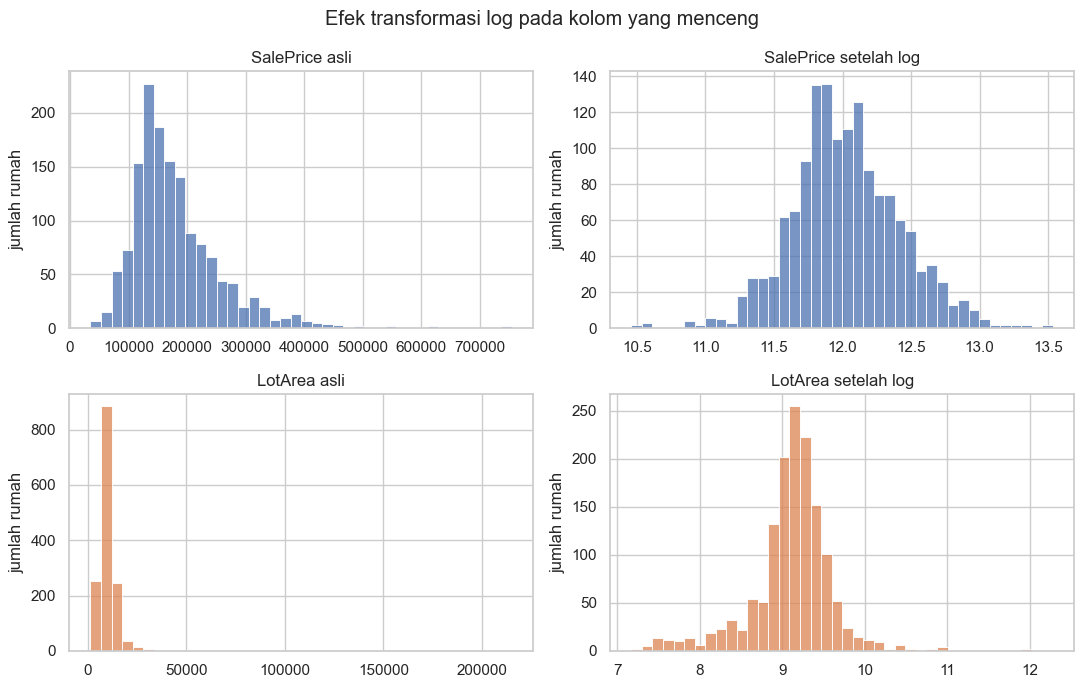

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

sns.histplot(df["SalePrice"], bins=40, color="#4c72b0", ax=axes[0, 0])
axes[0, 0].set_title("SalePrice asli")
sns.histplot(df_trans["SalePrice_log"], bins=40, color="#4c72b0", ax=axes[0, 1])
axes[0, 1].set_title("SalePrice setelah log")

sns.histplot(df["LotArea"], bins=40, color="#dd8452", ax=axes[1, 0])
axes[1, 0].set_title("LotArea asli")
sns.histplot(df_trans["LotArea"], bins=40, color="#dd8452", ax=axes[1, 1])
axes[1, 1].set_title("LotArea setelah log")

for ax in axes.ravel():
    ax.set_xlabel("")
    ax.set_ylabel("jumlah rumah")

fig.suptitle("Efek transformasi log pada kolom yang menceng")
plt.tight_layout()
plt.show()

Bedanya kelihatan jelas. `SalePrice` yang tadinya punya ekor panjang ke kanan (skewness 1,88) berubah jadi mendekati normal (0,12). `LotArea` lebih ekstrem lagi, dari 12,57 jadi hampir simetris.

Ada beberapa kolom yang tetap menceng walau sudah dilog, misalnya `PoolArea` dan `3SsnPorch`. Itu karena isinya hampir semua nol, jadi masalahnya bukan skala tapi memang fasilitasnya jarang ada. `BsmtUnfSF` malah jadi lebih parah setelah dilog, makanya dikembalikan ke nilai aslinya.

### 4.2 Standarisasi

Saya pakai standarisasi (z-score) bukan normalisasi min-max. Alasannya, outlier yang tadi sengaja dipertahankan akan bikin min-max jadi timpang: satu rumah dengan tanah 215 ribu kaki persegi akan menarik batas atas sendirian sampai mayoritas data menumpuk di dekat nol. Standarisasi tidak sepeka itu. Lagi pula PCA nanti butuh data yang sudah terpusat di nol.

In [26]:
scaler = StandardScaler()
df_trans[fitur_num] = scaler.fit_transform(df_trans[fitur_num])

df_trans[fitur_num].describe().T[["mean", "std", "min", "max"]].head(8).round(2)

,mean,std,min,max
LotFrontage,0.0,1.0,-3.50,4.78
LotArea,-0.0,1.0,-3.77,6.17
OverallQual,-0.0,1.0,-3.70,2.84
OverallCond,0.0,1.0,-4.11,3.08
YearBuilt,0.0,1.0,-3.29,1.28
YearRemodAdd,0.0,1.0,-1.69,1.22
MasVnrArea,0.0,1.0,-0.81,2.01
BsmtFinSF1,-0.0,1.0,-1.41,1.16


Rata-ratanya jadi 0 dan standar deviasinya 1 untuk semua fitur numerik. Kolom `SalePrice` sengaja tidak ikut distandarisasi karena dia targetnya, bukan fitur.

### 4.3 One-hot encoding

In [27]:
kolom_kat = df_trans.select_dtypes(exclude=np.number).columns.tolist()

ringkas_kat = pd.DataFrame({
    "jumlah_kategori": df_trans[kolom_kat].nunique(),
    "kategori_terbanyak": df_trans[kolom_kat].apply(lambda s: s.value_counts().index[0]),
}).sort_values("jumlah_kategori", ascending=False)

print("Jumlah kolom kategorikal:", len(kolom_kat))
print("Total kategori unik     :", int(ringkas_kat["jumlah_kategori"].sum()))
ringkas_kat.head(8)

Jumlah kolom kategorikal: 39
Total kategori unik     : 261


,jumlah_kategori,kategori_terbanyak
Neighborhood,25,NAmes
Exterior2nd,16,VinylSd
MSSubClass,15,20
Exterior1st,15,VinylSd
Condition1,9,Norm
SaleType,9,WD
HouseStyle,8,1Story
Condition2,8,Norm


In [28]:
df_enc = pd.get_dummies(df_trans, columns=kolom_kat, drop_first=True, dtype=int)

print("Sebelum encoding:", df_trans.shape)
print("Sesudah encoding:", df_enc.shape)
df_enc.iloc[:5, :8]

Sebelum encoding: (1458, 76)
Sesudah encoding: (1458, 259)


,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1
0,-0.079885,-0.129624,0.658506,-0.517649,1.052959,0.880362,1.207635,0.781657
1,0.558193,0.118819,-0.068293,2.177825,0.158428,-0.428115,-0.805570,0.890540
2,0.058613,0.427643,0.658506,-0.517649,0.986698,0.831900,1.135442,0.656962
3,-0.325343,0.108651,0.658506,-0.517649,-1.862551,-0.718888,-0.805570,0.386556
4,0.708377,0.889295,1.385305,-0.517649,0.953567,0.734975,1.427727,0.756612


Dari 39 kolom kategorikal yang isinya 261 kategori berbeda, keluar 222 kolom dummy. Saya pakai `drop_first=True` supaya satu kategori jadi acuan dan tidak muncul kolom yang nilainya bisa ditebak dari kolom lain (jebakan dummy variable). Konsekuensinya jumlah kolom membengkak dari 76 jadi 259, dan itu justru yang bikin tahap reduksi dimensi berikutnya jadi perlu.

## 5. Reduksi Dimensi

### 5.1 Analisis korelasi

Korelasinya saya hitung dari data sebelum distandarisasi, biar angkanya gampang ditafsirkan. Nilai korelasi Pearson sendiri tidak berubah oleh standarisasi.

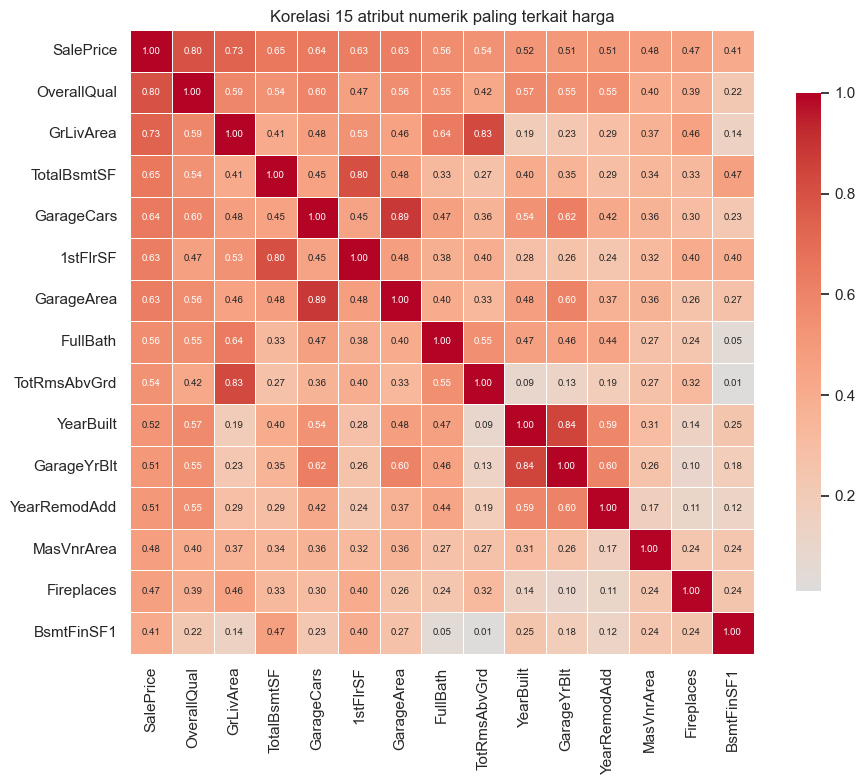

In [29]:
korr = df[fitur_num + ["SalePrice"]].corr()
teratas = korr["SalePrice"].abs().sort_values(ascending=False).head(15).index

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(korr.loc[teratas, teratas], annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.4, annot_kws={"size": 7},
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Korelasi 15 atribut numerik paling terkait harga")
plt.tight_layout()
plt.show()

In [30]:
pasangan = []
for i, a in enumerate(fitur_num):
    for b in fitur_num[i + 1:]:
        r = korr.loc[a, b]
        if abs(r) > 0.75:
            pasangan.append({
                "fitur_1": a,
                "fitur_2": b,
                "korelasi": round(r, 3),
                "r1_ke_harga": round(korr.loc[a, "SalePrice"], 3),
                "r2_ke_harga": round(korr.loc[b, "SalePrice"], 3),
            })

pd.DataFrame(pasangan)

,fitur_1,fitur_2,korelasi,r1_ke_harga,r2_ke_harga
0,YearBuilt,GarageYrBlt,0.845,0.524,0.509
1,TotalBsmtSF,1stFlrSF,0.804,0.651,0.632
2,GrLivArea,TotRmsAbvGrd,0.829,0.735,0.538
3,GarageCars,GarageArea,0.887,0.641,0.629


Ada empat pasangan yang korelasinya di atas 0,75, dan semuanya masuk akal kalau dipikir:

- `GarageCars` dan `GarageArea` (0,89) sama-sama mengukur besar garasi, cuma satuannya beda (muat berapa mobil vs berapa kaki persegi).
- `YearBuilt` dan `GarageYrBlt` (0,85) hampir selalu sama karena garasi biasanya dibangun bareng rumahnya.
- `GrLivArea` dan `TotRmsAbvGrd` (0,83) sama saja, rumah yang luas kamarnya juga lebih banyak.
- `TotalBsmtSF` dan `1stFlrSF` (0,80) berhubungan karena basement umumnya seluas lantai dasar di atasnya.

Dari tiap pasangan saya buang satu, yang dipertahankan adalah yang korelasinya ke harga lebih tinggi. Jadi yang keluar: `GarageArea`, `GarageYrBlt`, `TotRmsAbvGrd`, dan `1stFlrSF`.

In [31]:
buang_redundan = ["GarageArea", "GarageYrBlt", "TotRmsAbvGrd", "1stFlrSF"]
df_enc = df_enc.drop(columns=buang_redundan)

print("Kolom setelah membuang yang redundan:", df_enc.shape)

Kolom setelah membuang yang redundan: (1458, 255)


### 5.2 PCA

PCA saya jalankan pada seluruh matriks fitur, jadi kolom numerik dan kolom hasil one-hot ikut semua. Karena kolom dummy isinya 0/1 sementara kolom numerik sudah berskala z-score, semuanya saya standarisasi sekali lagi supaya PCA tidak cuma mengikuti kolom yang variansinya paling besar.

In [32]:
X = df_enc.drop(columns=["SalePrice", "SalePrice_log"])
y = df_enc["SalePrice_log"]

X_skala = StandardScaler().fit_transform(X.astype(float))

pca = PCA().fit(X_skala)
kumulatif = np.cumsum(pca.explained_variance_ratio_)

print("Jumlah fitur sebelum PCA:", X.shape[1])
for ambang in [0.80, 0.90, 0.95]:
    print(f"{ambang:.0%} variansi butuh {int(np.argmax(kumulatif >= ambang)) + 1} komponen")
print()
print("Variansi 5 komponen pertama (%):", (pca.explained_variance_ratio_[:5] * 100).round(2))

Jumlah fitur sebelum PCA: 253
80% variansi butuh 100 komponen
90% variansi butuh 134 komponen
95% variansi butuh 158 komponen

Variansi 5 komponen pertama (%): [6.54 3.25 2.93 2.37 2.21]


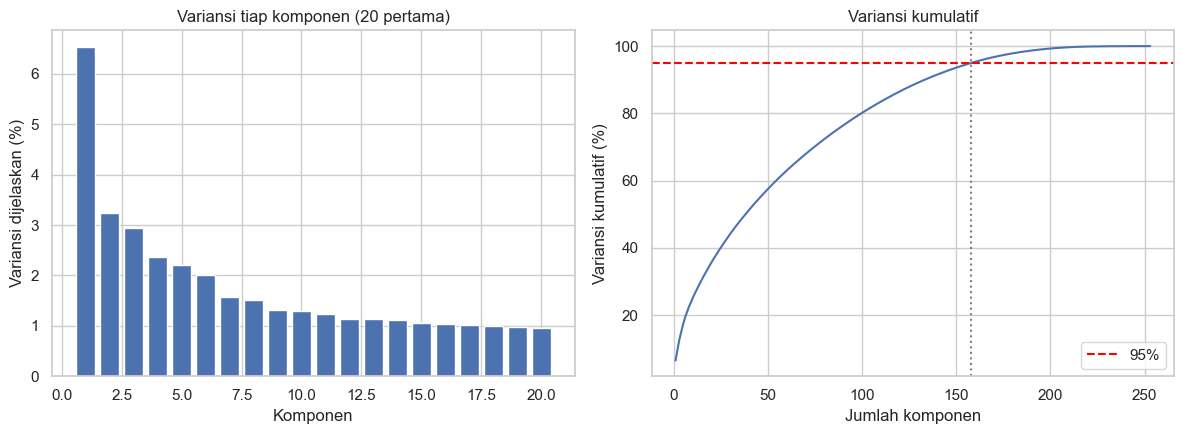

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].bar(range(1, 21), pca.explained_variance_ratio_[:20] * 100, color="#4c72b0")
ax[0].set_title("Variansi tiap komponen (20 pertama)")
ax[0].set_xlabel("Komponen")
ax[0].set_ylabel("Variansi dijelaskan (%)")

ax[1].plot(range(1, len(kumulatif) + 1), kumulatif * 100, color="#4c72b0")
ax[1].axhline(95, color="red", linestyle="--", label="95%")
ax[1].axvline(int(np.argmax(kumulatif >= 0.95)) + 1, color="gray", linestyle=":")
ax[1].set_title("Variansi kumulatif")
ax[1].set_xlabel("Jumlah komponen")
ax[1].set_ylabel("Variansi kumulatif (%)")
ax[1].legend()

plt.tight_layout()
plt.show()

Hasilnya tidak seindah yang dibayangkan: dari 253 fitur, buat menampung 95% variansi masih butuh 158 komponen. Penyusutannya cuma sekitar 38%, dan komponen pertama saja isinya 6,5% variansi.

Penyebabnya kolom hasil one-hot. Kolom dummy itu jarang (sebagian besar isinya nol) dan antar kategori hampir tidak saling berhubungan, jadi tiap kolom membawa variansinya sendiri-sendiri dan susah diringkas jadi sedikit komponen. Kalau PCA dijalankan pada fitur numeriknya saja, hasilnya jauh lebih padat.

In [34]:
fitur_num_sisa = [k for k in fitur_num if k not in buang_redundan]

pca_num = PCA().fit(df_enc[fitur_num_sisa].astype(float))
kum_num = np.cumsum(pca_num.explained_variance_ratio_)

print("Jumlah fitur numerik:", len(fitur_num_sisa))
for ambang in [0.80, 0.90, 0.95]:
    print(f"{ambang:.0%} variansi butuh {int(np.argmax(kum_num >= ambang)) + 1} komponen")

Jumlah fitur numerik: 31
80% variansi butuh 16 komponen
90% variansi butuh 21 komponen
95% variansi butuh 24 komponen


Terbukti: 31 fitur numerik cukup diwakili 24 komponen untuk 95% variansi, bahkan 16 komponen sudah menampung 80%. Bandingkan dengan versi lengkapnya yang butuh 100 komponen untuk 80%.

Untuk dataset ini PCA berguna sebagai alat lihat struktur data, bukan buat memangkas kolom besar-besaran. Reduksi yang benar-benar efektif justru datang dari langkah sebelumnya, yaitu membuang kolom yang isinya hampir kosong, kolom seragam, dan kolom yang saling berkorelasi tinggi.

In [35]:
pca_pakai = PCA(n_components=0.95, random_state=42)
komponen = pca_pakai.fit_transform(X_skala)

print("Bentuk data setelah PCA:", komponen.shape)
print("Korelasi PC1 dengan harga (log):", round(np.corrcoef(komponen[:, 0], y)[0, 1], 3))
print("Korelasi PC2 dengan harga (log):", round(np.corrcoef(komponen[:, 1], y)[0, 1], 3))

Bentuk data setelah PCA: (1458, 158)
Korelasi PC1 dengan harga (log): 0.828
Korelasi PC2 dengan harga (log): 0.056


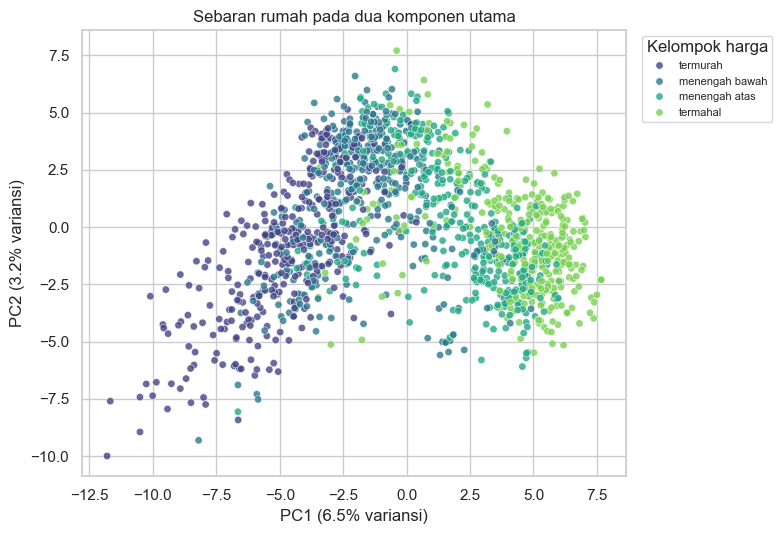

In [36]:
kuartil = pd.qcut(df["SalePrice"], 4, labels=["termurah", "menengah bawah", "menengah atas", "termahal"])

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(x=komponen[:, 0], y=komponen[:, 1], hue=kuartil, palette="viridis",
                alpha=0.8, s=28, ax=ax)
ax.set_title("Sebaran rumah pada dua komponen utama")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variansi)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variansi)")
ax.legend(title="Kelompok harga", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [37]:
muatan = pd.Series(pca.components_[0], index=X.columns).sort_values(key=abs, ascending=False)
print("Fitur paling berpengaruh di PC1:")
print(muatan.head(10).round(3).to_string())

Fitur paling berpengaruh di PC1:
YearBuilt           0.207
OverallQual         0.192
ExterQual_TA       -0.177
Foundation_PConc    0.176
GarageCars          0.173
ExterQual_Gd        0.168
YearRemodAdd        0.168
KitchenQual_TA     -0.152
BsmtQual_TA        -0.152
FullBath            0.144


Walau PC1 cuma menampung 6,5% variansi, arahnya ternyata bermakna. Korelasinya dengan harga (log) 0,83, dan di scatter plot kelompok rumah termurah ngumpul di kiri sementara yang termahal di kanan. Kalau dilihat muatannya, PC1 didominasi `YearBuilt`, `OverallQual`, `Foundation_PConc`, dan `ExterQual` -- pada dasarnya PC1 ini mengukur "rumah baru dan berkualitas bagus" lawan "rumah tua dan biasa saja". PC2 sebaliknya, korelasinya ke harga cuma 0,06, jadi dia menangkap variasi lain yang tidak ada hubungannya dengan harga.

## 6. Dataset Akhir

Yang saya simpan adalah data hasil praproses lengkap: sudah bersih dari nilai hilang, dua baris janggal dibuang, kolom miring dilog, fitur numerik distandarisasi, kategori sudah one-hot, dan empat kolom redundan dibuang. Hasil PCA tidak ikut disimpan karena bentuknya sudah tidak bisa ditelusuri lagi ke atribut aslinya; PCA di sini dipakai sebagai analisis, bukan sebagai output akhir.

In [38]:
df_akhir = df_enc.round(4)
df_akhir.to_csv("5054251051_Rayyan_Muhtar_Ali_Tugas_Praproses_Data.csv", index=False)

print("Ukuran dataset akhir :", df_akhir.shape)
print("Sisa nilai hilang    :", int(df_akhir.isna().sum().sum()))
print("Kolom numerik asli   :", len(fitur_num_sisa))
print("Kolom hasil one-hot  :", df_akhir.shape[1] - len(fitur_num_sisa) - 2)
df_akhir.iloc[:5, :10]

Ukuran dataset akhir : (1458, 255)
Sisa nilai hilang    : 0
Kolom numerik asli   : 31
Kolom hasil one-hot  : 222


,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF
0,-0.0799,-0.1296,0.6585,-0.5176,1.0530,0.8804,1.2076,0.7817,-0.3556,-0.9438
1,0.5582,0.1188,-0.0683,2.1778,0.1584,-0.4281,-0.8056,0.8905,-0.3556,-0.6406
2,0.0586,0.4276,0.6585,-0.5176,0.9867,0.8319,1.1354,0.6570,-0.3556,-0.3012
3,-0.3253,0.1087,0.6585,-0.5176,-1.8626,-0.7189,-0.8056,0.3866,-0.3556,-0.0613
4,0.7084,0.8893,1.3853,-0.5176,0.9536,0.7350,1.4277,0.7566,-0.3556,-0.1745


In [39]:
ringkasan = pd.DataFrame([
    ["Data mentah", 1460, 81],
    ["Buang Id dan 4 kolom yang hilang > 50%", 1460, 76],
    ["Buang Utilities (isinya seragam)", 1460, 75],
    ["Buang 2 baris penjualan belum selesai", 1458, 75],
    ["Tambah kolom SalePrice_log", 1458, 76],
    ["Setelah one-hot encoding", 1458, 259],
    ["Buang 4 kolom redundan", 1458, 255],
], columns=["tahap", "baris", "kolom"])

ringkasan

,tahap,baris,kolom
0,Data mentah,1460,81
1,Buang Id dan 4 kolom yang hilang > 50%,1460,76
2,Buang Utilities (isinya seragam),1460,75
3,Buang 2 baris penjualan belum selesai,1458,75
4,Tambah kolom SalePrice_log,1458,76
5,Setelah one-hot encoding,1458,259
6,Buang 4 kolom redundan,1458,255


## 7. Laporan

### Dataset dan tujuan

Dataset yang dipakai adalah *House Prices - Advanced Regression Techniques* dari Kaggle, file `train.csv`, berisi **1460 baris dan 81 kolom** data penjualan rumah di Ames, Iowa, antara 2006 sampai 2010. Satu baris mewakili satu transaksi rumah. Kolomnya ada 38 numerik dan 43 kategorikal, mulai dari ukuran (`LotArea`, `GrLivArea`, `TotalBsmtSF`), umur bangunan (`YearBuilt`, `YearRemodAdd`), fasilitas (garasi, basement, perapian, kolam), sampai penilaian kualitas dan kondisi yang bentuknya ordinal seperti `OverallQual` 1-10 atau `ExterQual` Ex/Gd/TA/Fa. Targetnya `SalePrice`.

Tujuannya menyiapkan data ini supaya siap dipakai model: tidak ada nilai kosong, outlier sudah diputuskan mau diapakan, skala antar kolom sebanding, kolom kategorikal sudah jadi angka, dan dimensinya tidak membengkak tanpa alasan.

### Langkah 1: membaca data dengan benar

Sebelum membersihkan apa pun, ada satu jebakan yang harus dibereskan dulu. Di file aslinya nilai kosong ditulis `NA`, sementara `MasVnrType` punya kategori sah bernama `None` yang artinya rumahnya tidak pakai lapisan batu hias. Karena `None` masuk daftar kata yang otomatis dianggap kosong oleh pandas, kolom ini kelihatan hilang 59,7% (872 baris) padahal yang benar-benar kosong cuma 8 baris (0,55%).

Kalau dibiarkan, `MasVnrType` akan kena aturan pembuangan kolom di atas 50% padahal datanya utuh. Jadi file dibaca ulang dengan `keep_default_na=False` dan `na_values=["NA", ""]`. Setelah itu total sel kosong yang sebenarnya adalah 6965, tersebar di 19 kolom.

### Langkah 2: pembersihan nilai hilang

Empat kolom melewati batas 50% dan dibuang: `PoolQC` (99,52%), `MiscFeature` (96,30%), `Alley` (93,77%), dan `Fence` (80,75%). Kolom `Id` juga dibuang karena cuma nomor urut. Selain jarang terisi, keempatnya isinya hampir seragam. `PoolQC` misalnya, cuma 7 dari 1460 rumah yang punya kolam renang.

Sisa 15 kolom ditangani menurut penyebab kosongnya, bukan diseragamkan:

| Kelompok | Kolom | Jumlah hilang | Cara mengisi |
|---|---|---|---|
| Fasilitas tidak ada | FireplaceQu | 690 (47,26%) | kategori `None` |
| Fasilitas tidak ada | 5 kolom garasi | 81 (5,55%) | `None`, `GarageYrBlt` pakai `YearBuilt` |
| Fasilitas tidak ada | 5 kolom basement | 37-38 (2,5%) | `None` |
| Benar-benar hilang | BsmtExposure, BsmtFinType2 | 1 baris | modus |
| Benar-benar hilang | MasVnrType, MasVnrArea | 8 (0,55%) | `None` dan 0 |
| Benar-benar hilang | Electrical | 1 (0,07%) | modus (`SBrkr`) |
| Benar-benar hilang | LotFrontage | 259 (17,74%) | median per `Neighborhood` |

Yang jadi kunci di sini pemeriksaan silang. Jumlah `FireplaceQu` yang kosong tepat 690, sama persis dengan jumlah rumah yang `Fireplaces`-nya 0. Begitu juga `GarageType` (81 kosong, 81 rumah `GarageArea` = 0) dan `BsmtQual` (37 kosong, 37 rumah `TotalBsmtSF` = 0). Artinya kosongnya bukan data hilang, tapi memang rumahnya tidak punya fasilitas itu, jadi tepatnya diisi kategori `None`, bukan ditambal modus.

Pengecualiannya `BsmtExposure` dan `BsmtFinType2` yang kosongnya 38, satu lebih banyak dari jumlah rumah tanpa basement. Satu baris itu benar-benar hilang datanya, dan cuma baris itu yang diisi modus.

Untuk `LotFrontage` tidak ada kolom pembanding karena semua rumah pasti punya sisi depan. Pengisiannya pakai median per kompleks perumahan dengan alasan kapling dalam satu kompleks biasanya seragam, dan hasilnya memang aman: median bergeser dari 69,0 ke 70,0, standar deviasi turun tipis dari 24,28 ke 22,43. Setelah semua langkah ini nilai hilang tersisa 0.

### Langkah 3: konsistensi data

Empat pemeriksaan logika dijalankan dan semuanya lolos: tidak ada baris duplikat, tidak ada nilai numerik negatif, tidak ada rumah yang tanggal renovasinya mendahului tanggal dibangun, dan penjumlahan luas lantai 1 + lantai 2 + lantai kualitas rendah selalu sama dengan `GrLivArea`.

Yang bermasalah justru kolom `Utilities`: 1459 dari 1460 baris isinya `AllPub`. Kolom yang isinya satu nilai begini tidak bisa membedakan apa pun, jadi dibuang. Selain itu `MSSubClass` tersimpan sebagai angka padahal isinya kode tipe bangunan (20, 60, 120, ...), jadi diubah ke teks supaya tidak ikut distandarisasi seolah-olah 120 lebih besar dari 20. Setelah tahap ini bentuk data jadi 1460 x 75.

### Langkah 4: outlier

Deteksinya pakai aturan IQR. Hasilnya 31 dari 36 kolom numerik punya outlier, dengan proporsi terbesar di `EnclosedPorch` (208 baris, 14,25%), `BsmtFinSF2` (167 baris, 11,44%), dan `OverallCond` (125 baris, 8,56%).

Angka itu kelihatan besar, tapi setelah boxplot dan sebarannya dilihat, sebagian besar bukan kesalahan data. Kolom seperti `EnclosedPorch`, `ScreenPorch`, dan `MasVnrArea` mayoritas isinya 0 karena fasilitasnya memang tidak umum, sehingga rumah yang kebetulan punya langsung dianggap ekstrem oleh IQR. Sementara `LotArea` dan `SalePrice` memang menceng ke kanan karena di pasar rumah memang ada rumah bertanah sangat luas dan rumah mewah. Membuang semuanya berarti membuang ratusan baris sekaligus menghapus segmen rumah mahal yang justru penting.

Yang dibuang cuma 2 baris, dan alasannya spesifik. Scatter plot luas bangunan lawan harga memperlihatkan dua rumah dengan `GrLivArea` 4676 dan 5642 kaki persegi tapi harganya di bawah 200 ribu dolar, padahal dua rumah lain seukuran laku 745 ribu dan 755 ribu dengan kualitas bangunan sama-sama 10. Kolom `SaleCondition` menjelaskan kenapa: dua rumah itu berstatus `Partial`, dijual dalam keadaan belum selesai dibangun, jadi harganya tidak mencerminkan nilai rumah jadi. Ukuran data jadi 1458 x 75.

Sisa outlier tidak dihapus dan tidak dipotong, tapi juga tidak dibiarkan mengganggu. Efek cencengannya ditangani di tahap berikutnya lewat transformasi log.

### Langkah 5: transformasi

Ada tiga transformasi yang dilakukan berurutan.

**Log.** Dari 35 fitur numerik, 19 punya |skewness| di atas 0,75. Log1p diterapkan hanya kalau memang memperbaiki, dan 18 dari 19 kolom membaik. Hasilnya cukup drastis: `LotArea` dari 12,57 jadi -0,18, `MiscVal` dari 24,46 jadi 5,17, `GrLivArea` dari 1,01 jadi -0,07. Target `SalePrice` juga dibuatkan versi log (`SalePrice_log`) dan skewness-nya turun dari 1,88 ke 0,12, praktis normal. Satu kolom, `BsmtUnfSF`, malah jadi lebih menceng setelah dilog jadi dikembalikan ke nilai aslinya. Beberapa kolom seperti `PoolArea` dan `3SsnPorch` tetap menceng walau sudah dilog, karena masalahnya bukan skala melainkan isinya hampir semua nol.

**Standarisasi.** Semua fitur numerik distandarisasi dengan `StandardScaler` sehingga rata-ratanya 0 dan standar deviasinya 1. Saya pilih standarisasi, bukan normalisasi min-max, karena outlier yang sengaja dipertahankan akan membuat min-max timpang: satu rumah dengan tanah 215 ribu kaki persegi akan menarik batas atas sendirian sampai mayoritas data menumpuk di dekat nol. Standarisasi juga syarat yang wajar sebelum PCA. Kolom `SalePrice` tidak ikut distandarisasi karena posisinya target, bukan fitur.

**One-hot encoding.** 39 kolom kategorikal dengan total 261 kategori diubah jadi 222 kolom dummy memakai `drop_first=True`, supaya satu kategori jadi acuan dan tidak muncul kolom yang nilainya bisa ditebak dari kolom lain. Jumlah kolom naik dari 76 jadi 259.

### Langkah 6: reduksi dimensi

**Analisis korelasi.** Dari seluruh pasangan fitur numerik, ada empat pasangan dengan |korelasi| di atas 0,75 dan semuanya punya penjelasan yang logis:

| Pasangan | Korelasi | Yang dibuang | Alasan |
|---|---|---|---|
| GarageCars - GarageArea | 0,887 | GarageArea | dua-duanya mengukur besar garasi |
| YearBuilt - GarageYrBlt | 0,845 | GarageYrBlt | garasi umumnya dibangun bareng rumahnya |
| GrLivArea - TotRmsAbvGrd | 0,829 | TotRmsAbvGrd | rumah luas otomatis kamarnya banyak |
| TotalBsmtSF - 1stFlrSF | 0,804 | 1stFlrSF | basement seluas lantai dasar di atasnya |

Dari tiap pasangan yang dipertahankan adalah yang korelasinya ke `SalePrice` lebih tinggi. Kolom jadi 255.

**PCA.** PCA dijalankan pada 253 fitur (semua kolom kecuali dua kolom harga) setelah distandarisasi ulang supaya kolom dummy yang berisi 0/1 tidak kalah bobot dari kolom numerik. Hasilnya tidak sedramatis yang diharapkan: 95% variansi masih butuh 158 komponen, 90% butuh 134, dan 80% butuh 100. Komponen pertama sendiri cuma menampung 6,54% variansi.

Penyebabnya kolom hasil one-hot: isinya jarang (mayoritas nol) dan antar kategori nyaris tidak saling berhubungan, jadi tiap kolom membawa variansi sendiri yang sulit diringkas. Sebagai pembanding, kalau PCA dijalankan pada 31 fitur numerik saja, 95% variansi cukup diwakili 24 komponen dan 80% cukup 16 komponen.

Meski penyusutannya kecil, arah komponen pertamanya tetap bermakna. Korelasi PC1 dengan harga (log) sebesar 0,828, dan di scatter plot PC1 lawan PC2 kelompok rumah termurah mengumpul di kiri sementara yang termahal di kanan. Muatan terbesar PC1 datang dari `YearBuilt` (0,207), `OverallQual` (0,192), `ExterQual_TA` (-0,177), dan `Foundation_PConc` (0,176), jadi PC1 pada dasarnya sumbu "rumah baru berkualitas bagus" lawan "rumah tua biasa saja". PC2 sebaliknya, korelasinya ke harga cuma 0,056, jadi dia menangkap variasi yang tidak ada hubungannya dengan harga.

### Ringkasan dataset akhir

| | Sebelum | Sesudah |
|---|---|---|
| Baris | 1460 | 1458 |
| Kolom | 81 | 255 |
| Sel kosong | 6965 | 0 |
| Kolom kategorikal | 43 | 0 (sudah jadi 222 kolom dummy) |
| Skewness SalePrice | 1,88 | 0,12 (versi log) |

Dataset akhir disimpan sebagai `5054251051_Rayyan_Muhtar_Ali_Tugas_Praproses_Data.csv` berisi 1458 baris dan 255 kolom: 31 fitur numerik yang sudah dilog dan distandarisasi, 222 kolom hasil one-hot, serta dua kolom harga (`SalePrice` asli dan `SalePrice_log`). Tidak ada satu pun nilai kosong.

Hasil PCA sengaja tidak ikut disimpan. Komponen utama sudah tidak bisa ditelusuri balik ke atribut aslinya, sementara dataset ini kemungkinan masih dipakai untuk analisis lanjutan yang butuh nama kolom yang bisa dibaca. PCA di sini fungsinya sebagai alat memeriksa struktur data, bukan sebagai bentuk akhir datanya.

### Catatan

Pelajaran yang paling terasa dari tugas ini, praproses tidak bisa dijalankan sebagai resep yang sama untuk semua kolom. Nilai kosong di dataset ini ada dua jenis yang beda penanganannya, dan bedanya baru ketahuan setelah dicocokkan dengan kolom lain. Outlier versi IQR jumlahnya banyak tapi hampir semuanya data yang sah, jadi menghapusnya justru merusak. Bahkan cara membaca file pun ternyata bisa bikin satu kolom utuh kelihatan rusak.

Satu hal lagi yang cukup mengubah cara pandang: reduksi dimensi yang paling berdampak di sini bukan PCA, melainkan langkah-langkah sederhana sebelumnya, yaitu membuang kolom yang hampir kosong, kolom yang isinya seragam, dan kolom yang informasinya sudah diwakili kolom lain.